In [1]:
from pathlib import Path
from IPython.display import HTML, display
css = Path("../../../css/rtl.css").read_text(encoding="utf-8")
display(HTML(f"<style>{css}</style>"))

# فصل ۶ — تکنیک‌های یادگیری تجمعی (Ensemble Learning)
## درس ۶: رأی‌گیری در طبقه‌بندی و روش‌های میانگین‌گیری

تجمیع‌گرها چندین مدل را با هم ترکیب می‌کنند تا پیش‌بینی‌گری بسازند که معمولاً **دقیق‌تر**، **پایدارتر** و **مقاوم‌تر**
از هر مدل تکی است. در این درس روی مستقیم‌ترین و در عین حال پرکاربردترین خانوادهٔ تجمیع تمرکز می‌کنیم:

- **Voting (طبقه‌بندی)**: ترکیب پیش‌بینی‌های برچسب (Hard Vote) یا ترکیب احتمال‌های کلاس (Soft Vote).
- **Averaging (رگرسیون و طبقه‌بندی احتمالاتی)**: ترکیب خروجی‌های حقیقی با میانگین ساده یا وزن‌دار.

با وجود سادگی، رأی‌گیری/میانگین‌گیری دقیقاً ریاضیات اصلیِ پشت تجمیع را نشان می‌دهند:

- **کاهش واریانس**: میانگین‌گیری نوسانات پر واریانس مدل‌ها را خنثی می‌کند.
- **خنثی‌سازی خطا**: اگر مدل‌ها اشتباهات متفاوتی داشته باشند، خطاها تا حدی همدیگر را خنثی می‌کنند.
- **افزایش Margin** (طبقه‌بندی): رأی اکثریت می‌تواند «حاشیهٔ رأی» کلاس درست را نسبت به رقبا افزایش دهد.

### اهداف یادگیری

در پایان این نوت‌بوک باید بتوانید:

1. Hard و Soft Voting را با scikit-learn پیاده‌سازی کنید.
2. توضیح دهید چه زمانی Soft Voting بهتر است (و چه زمانی نه).
3. بفهمید چرا **کالیبراسیون احتمال** در Soft Voting یک موضوع کلیدی است.
4. میانگین‌گیری رگرسیون را با `VotingRegressor` انجام دهید و وزن‌های **داده‌محور** را با Cross-Validation محاسبه کنید.
5. سود/شکست تجمیع را با سنجش **تنوع** بین مدل‌های پایه تشخیص دهید.

> همهٔ فرمول‌ها در سلول‌های Markdown با `$ ... $` و `$$ ... $$` نوشته شده‌اند (نه `\( \)` یا `\[ \]`).

---


In [2]:
# Core scientific stack
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

# Sklearn utilities
from sklearn.model_selection import train_test_split, StratifiedKFold, KFold, cross_val_score, cross_val_predict
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    mean_squared_error, mean_absolute_error, r2_score, RocCurveDisplay
)
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Base learners
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingRegressor, RandomForestRegressor

# Voting ensembles
from sklearn.ensemble import VotingClassifier, VotingRegressor

# Probability calibration (important for soft voting)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

RNG = 42
np.random.seed(RNG)

import sklearn
print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("scikit-learn:", sklearn.__version__)


numpy: 2.1.2
pandas: 2.2.3
scikit-learn: 1.5.2


In [3]:
from pathlib import Path
from io import StringIO

DATA_ROOT = Path("../../../Datasets")

def read_csv_or_fallback(path: Path, fallback_head: str) -> pd.DataFrame:
    """Read a CSV from the repo path; if missing, fall back to an in-memory snippet.
    
    This keeps the notebook runnable even if you're previewing it outside the repository.
    """
    try:
        df = pd.read_csv(path)
        print(f"Loaded: {path}  shape={df.shape}")
        return df
    except FileNotFoundError:
        print(f"[WARN] File not found: {path}. Using fallback snippet instead.")
        return pd.read_csv(StringIO(fallback_head))

def peek(df: pd.DataFrame, n=5):
    display(df.head(n))
    print("shape:", df.shape)

def split_xy(df: pd.DataFrame, target_col: str):
    X = df.drop(columns=[target_col])
    y = df[target_col]
    return X, y


## ۱) قواعد تجمیع (ریاضیات ضروری)

### ۱.۱ Hard Voting (طبقه‌بندی)

فرض کنید $M$ طبقه‌بند $f_1,\dots,f_M$ داریم که برچسب کلاس را در $\{1,\dots,K\}$ خروجی می‌دهند.
Hard Voting کلاسی را انتخاب می‌کند که بیشترین رأی را گرفته است:

$$\hat{y}(x)=\arg\max_{k\in\{1,\dots,K\}} \sum_{m=1}^{M} \mathbf{1}\{f_m(x)=k\}$$

نسخهٔ وزن‌دار با وزن‌های نامنفی $w_m$:

$$\hat{y}(x)=\arg\max_{k} \sum_{m=1}^{M} w_m\,\mathbf{1}\{f_m(x)=k\}$$

**شکستن تساوی (Tie breaking)** — در چندکلاسه یا وقتی تعداد رأی‌دهنده‌ها زوج است مهم می‌شود:

- قطعی: انتخاب کوچک‌ترین اندیس کلاس (اغلب نامطلوب)
- تصادفی: شکستن تساوی به‌صورت رندوم (ارزیابی را نویزی می‌کند)
- مبتنی بر اولویت: اگر هدف شما Recall کلاس مثبت باشد، کلاس مثبت را ترجیح دهید

در scikit-learn تساوی‌ها طبق ترتیب داخلی حل می‌شوند. اگر تساوی برایتان مهم است، از تعداد رأی‌دهندهٔ فرد یا Soft Voting استفاده کنید.

### ۱.۲ Soft Voting (طبقه‌بندی)

Soft Voting فرض می‌کند هر طبقه‌بند احتمال کلاس‌ها $p_m(k\mid x)$ را خروجی می‌دهد.
تجمیع با میانگین (وزن‌دار) احتمال‌ها انجام می‌شود:

$$\hat{y}(x)=\arg\max_{k} \sum_{m=1}^{M} w_m\,p_m(k\mid x)$$

Soft Voting از نظر مفهومی به **مدل مخلوط** شبیه است: شما یک ترکیب محدب از توزیع‌های پیش‌بینی را می‌سازید.

### ۱.۳ Averaging (رگرسیون)

برای رگرسورهایی که خروجی حقیقی $f_m(x)\in\mathbb{R}$ می‌دهند:

- میانگین ساده: $$\hat{y}(x)=\frac{1}{M}\sum_{m=1}^{M} f_m(x)$$
- میانگین وزن‌دار: $$\hat{y}(x)=\sum_{m=1}^{M} w_m f_m(x),\quad w_m\ge 0,\ \sum_m w_m=1$$

### ۱.۴ میانگین‌گیری احتمال در برابر میانگین‌گیری لاجیت (logit)

اگر *احتمال‌ها* را میانگین بگیریم:

$$\bar{p}(k\mid x) = \sum_m w_m p_m(k\mid x)$$

اگر *لاجیت‌ها* (امتیازهای قبل از softmax) را میانگین بگیریم:

$$\bar{s}_k(x) = \sum_m w_m s_{m,k}(x),\quad \bar{p}(k\mid x)=\text{softmax}(\bar{s}(x))$$

این دو **معادل نیستند**. میانگین‌گیری لاجیت معمولاً توزیع تیزتری می‌دهد؛ میانگین‌گیری احتمال محافظه‌کارانه‌تر است.
`VotingClassifier(voting="soft")` احتمال‌ها را میانگین می‌گیرد.

---


## ۲) چرا تجمیع کمک می‌کند: استقلال افسانه است، هم‌بستگی اهرم اصلی است

### ۲.۱ خطای رأی اکثریت (دودویی، حالت مستقل)

در طبقه‌بندی دودویی، فرض کنید هر مدل پایه با احتمال $p<0.5$ خطا می‌کند و خطاها مستقل‌اند.
رأی اکثریت زمانی غلط است که حداقل نصف رأی‌دهنده‌ها غلط باشند:

$$\mathbb{P}(\text{vote wrong}) = \sum_{k=\lceil M/2 \rceil}^{M} {M\choose k} p^k(1-p)^{M-k}$$

اگر $p<0.5$ باشد، با افزایش $M$ این مقدار سریعاً کاهش می‌یابد.

**برداشت**: رأی‌گیری شبیه یک کُد تصحیح خطاست که از پیش‌بینی‌گرهای تکراری ساخته شده است.

### ۲.۲ خطاهای هم‌بسته: فرمول واریانس که باید حفظ کنید

در رگرسیون (یا خطاهای حقیقی)، فرض کنید خطای هر مدل $\varepsilon_m$ واریانس $\sigma^2$ دارد و هم‌بستگی زوجی $\rho$ است.
واریانس خطای میانگین به شکل زیر می‌شود:

$$\text{Var}(\bar{\varepsilon}) = \sigma^2\left(\rho + \frac{1-\rho}{M}\right)$$

- اگر $\rho=0$ (خطاهای بدون هم‌بستگی)، واریانس مانند $1/M$ کم می‌شود.
- اگر $\rho\to 1$، بهبود بسیار کم است.

پس فرمول موفقیت این است:

> **مدل‌های پایهٔ نسبتاً قوی + تنوع بالا**.

### ۲.۳ معیارهای تنوع (فهرست سریع)

می‌توانید تنوع بین دو طبقه‌بند را با معیارهای مبتنی بر عدم‌توافق اندازه بگیرید.

روی $N$ نمونه، برای دو طبقه‌بند $A$ و $B$ تعریف کنید:

- $N_{11}$: هر دو درست
- $N_{00}$: هر دو غلط
- $N_{10}$: A درست، B غلط
- $N_{01}$: A غلط، B درست

آنگاه:

- نرخ عدم‌توافق: $$\text{Dis}(A,B)=\frac{N_{10}+N_{01}}{N}$$
- Q-statistic: $$Q(A,B)=\frac{N_{11}N_{00}-N_{10}N_{01}}{N_{11}N_{00}+N_{10}N_{01}}$$

هم‌بستگی پایین/عدم‌توافق بالا *به‌خودی‌خود* کافی نیست؛ فقط وقتی خوب است که دقت هر مدل قابل‌قبول باقی بماند.

---


## ۳) طبقه‌بندی: ساخت درست Voting Ensembleها

کیفیت یک VotingClassifier به اندازهٔ انضباط مهندسی شماست. الگوی امن:

1. یک تعریف **یکپارچهٔ پیش‌پردازش** داشته باشید (تفکیک ستون‌های عددی/رده‌ای).
2. برای هر مدل پایه، پیش‌پردازش + مدل را داخل یک **Pipeline** قرار دهید.
3. Pipelineها را با `VotingClassifier` ترکیب کنید.

این کار جلوی باگ‌های ظریف را می‌گیرد، مثل:

- فیت کردن scalerها به‌صورت جداگانه روی splitهای مختلف
- ترتیب متفاوت one-hot برای دسته‌ها
- Leakage به خاطر پیش‌پردازش خارج از Cross-Validation

در این بخش از چند دیتاست طبقه‌بندی مخزن شما استفاده می‌کنیم:

- `iris.csv` (کوچک، تمیز، چندکلاسه)
- `diabetes.csv` (دودویی، نویزی)
- `drug200.csv` (عمدتاً رده‌ای)
- `Wine_Quality.csv` (تبدیل به طبقه‌بندی دودویی)

### شرط Soft Voting

`VotingClassifier(voting="soft")` نیاز دارد که هر مدل پایه `predict_proba` داشته باشد.

- Logistic regression، random forest، kNN: دارند.
- SVC: فقط با `probability=True` (کند) یا با کالیبراسیون (`CalibratedClassifierCV`).

---


In [4]:
# --- Load multiple classification datasets (repo paths) ---
iris_path = DATA_ROOT / "Classification" / "iris.csv"
diabetes_path = DATA_ROOT / "Classification" / "diabetes.csv"
glass_path = DATA_ROOT / "Classification" / "glass.csv"
drug_path = DATA_ROOT / "Classification" / "drug200.csv"
wine_path = DATA_ROOT / "Classification" / "Wine_Quality.csv"

iris_fallback = """sepal_length,sepal_width,petal_length,petal_width,classification
5.4,3.7,1.5,0.2,Iris-setosa
4.8,3.4,1.6,0.2,Iris-setosa
4.8,3,1.4,0.1,Iris-setosa
4.3,3,1.1,0.1,Iris-setosa
5.8,4,1.2,0.2,Iris-setosa
"""

diabetes_fallback = """Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,classification
6,148,72,35,0,33.6,0.627,50,Diabetic
1,85,66,29,0,26.6,0.351,31,Non-Diabetic
8,183,64,0,0,23.3,0.672,32,Diabetic
1,89,66,23,94,28.1,0.167,21,Non-Diabetic
0,137,40,35,168,43.1,2.288,33,Diabetic
"""

glass_fallback = """RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
1.52101,13.64,4.49,1.1,71.78,0.06,8.75,0.0,0.0,building_windows_float_processed
1.51761,13.89,3.6,1.36,72.73,0.48,7.83,0.0,0.0,building_windows_float_processed
1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,building_windows_float_processed
1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,building_windows_float_processed
1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,building_windows_float_processed
"""

drug_fallback = """Age,Sex,BP,Cholesterol,Na_to_K,Drug
23,F,HIGH,HIGH,25.355,DrugY
47,M,LOW,HIGH,13.093,drugC
47,M,LOW,HIGH,10.114,drugC
28,F,NORMAL,HIGH,7.798,drugX
61,F,LOW,HIGH,18.043,DrugY
22,F,NORMAL,HIGH,8.607,drugX
"""

wine_fallback = """fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
7,0.27,0.36,20.7,0.045,45,170,1.001,3,0.45,8.8,6
6.3,0.3,0.34,1.6,0.049,14,132,0.994,3.3,0.49,9.5,6
8.1,0.28,0.4,6.9,0.05,30,97,0.9951,3.26,0.44,10.1,6
7.2,0.23,0.32,8.5,0.058,47,186,0.9956,3.19,0.4,9.9,6
7.2,0.23,0.32,8.5,0.058,47,186,0.9956,3.19,0.4,9.9,6
"""

df_iris = read_csv_or_fallback(iris_path, iris_fallback)
df_diabetes = read_csv_or_fallback(diabetes_path, diabetes_fallback)
df_glass = read_csv_or_fallback(glass_path, glass_fallback)
df_drug = read_csv_or_fallback(drug_path, drug_fallback)
df_wine = read_csv_or_fallback(wine_path, wine_fallback)

print("Iris:"); peek(df_iris)
print("Diabetes:"); peek(df_diabetes)
print("Glass:"); peek(df_glass)
print("Drug:"); peek(df_drug)
print("Wine:"); peek(df_wine)


Loaded: ..\..\..\Datasets\Classification\iris.csv  shape=(150, 5)
Loaded: ..\..\..\Datasets\Classification\diabetes.csv  shape=(768, 9)
Loaded: ..\..\..\Datasets\Classification\glass.csv  shape=(214, 10)
Loaded: ..\..\..\Datasets\Classification\drug200.csv  shape=(200, 6)
Loaded: ..\..\..\Datasets\Classification\Wine_Quality.csv  shape=(4898, 12)
Iris:


,sepal_length,sepal_width,petal_length,petal_width,classification
0,5.4,3.7,1.5,0.2,Iris-setosa
1,4.8,3.4,1.6,0.2,Iris-setosa
2,4.8,3.0,1.4,0.1,Iris-setosa
3,4.3,3.0,1.1,0.1,Iris-setosa
4,5.8,4.0,1.2,0.2,Iris-setosa


shape: (150, 5)
Diabetes:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,classification
0,6,148,72,35,0,33.6,0.627,50,Diabetic
1,1,85,66,29,0,26.6,0.351,31,Non-Diabetic
2,8,183,64,0,0,23.3,0.672,32,Diabetic
3,1,89,66,23,94,28.1,0.167,21,Non-Diabetic
4,0,137,40,35,168,43.1,2.288,33,Diabetic


shape: (768, 9)
Glass:


...

shape: (214, 10)
Drug:


,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,DrugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,DrugY


shape: (200, 6)
Wine:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


shape: (4898, 12)


### ۳.۱ ساخت Pipelineهای قابل استفادهٔ مجدد

یک تابع می‌نویسیم که:

- ستون‌های عددی و رده‌ای را خودکار تشخیص دهد
- یک `ColumnTransformer` بسازد
- چند Pipeline طبقه‌بندی متنوع برگرداند

**چرا تنوع مهم است؟** اگر مدل‌های تقریباً یکسان را روی نمایش یکسان داده ترکیب کنید، خطاهایشان هم‌بسته می‌شود
و تجمیع تقریباً مثل یک مدل تکی رفتار می‌کند.

بعداً تنوع را با معیارهایی مثل disagreement و Q-statistic اندازه می‌گیریم.

---


In [5]:
def build_classification_pipelines(df: pd.DataFrame, target_col: str, for_soft_voting: bool):
    X = df.drop(columns=[target_col])
    y = df[target_col]

    num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = [c for c in X.columns if c not in num_cols]

    numeric_tf = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])

    categorical_tf = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])

    pre = ColumnTransformer(
        transformers=[
            ("num", numeric_tf, num_cols),
            ("cat", categorical_tf, cat_cols),
        ],
        remainder="drop"
    )

    # Diverse base learners
    lr = Pipeline(steps=[
        ("pre", pre),
        ("clf", LogisticRegression(max_iter=800, n_jobs=None, random_state=RNG))
    ])

    knn = Pipeline(steps=[
        ("pre", pre),
        ("clf", KNeighborsClassifier(n_neighbors=15))
    ])

    tree = Pipeline(steps=[
        ("pre", pre),
        ("clf", DecisionTreeClassifier(max_depth=6, random_state=RNG))
    ])

    rf = Pipeline(steps=[
        ("pre", pre),
        ("clf", RandomForestClassifier(
            n_estimators=350,
            max_depth=None,
            min_samples_leaf=2,
            random_state=RNG,
            n_jobs=-1
        ))
    ])

    # SVC probability is needed for soft voting; otherwise use fast hard-vote SVC
    svc = Pipeline(steps=[
        ("pre", pre),
        ("clf", SVC(C=2.0, kernel="rbf", gamma="scale", probability=for_soft_voting, random_state=RNG))
    ])

    return (X, y), {
        "lr": lr,
        "knn": knn,
        "tree": tree,
        "rf": rf,
        "svc": svc,
    }

def eval_acc(model, X, y, cv):
    scores = cross_val_score(model, X, y, cv=cv, scoring="accuracy")
    return scores.mean(), scores.std()

def eval_auc_binary(model, X, y, cv, pos_label=None):
    # Get probabilities via CV to compute AUC robustly
    # Works for string labels too.
    if pos_label is None:
        # assume positive label is the last class in sorted order
        pos_label = sorted(pd.unique(y))[-1]
    proba = cross_val_predict(model, X, y, cv=cv, method="predict_proba")
    classes = model.classes_ if hasattr(model, "classes_") else None
    # model.classes_ not available before fitting; infer from proba order by fitting once
    model.fit(X, y)
    classes = list(model.classes_)
    idx = classes.index(pos_label)
    p = proba[:, idx]
    y01 = (y == pos_label).astype(int)
    return roc_auc_score(y01, p)

def show_cm(model, X, y, title):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=RNG, stratify=y
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred, labels=np.unique(y_test))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y_test))
    disp.plot(values_format="d")
    plt.title(title)
    plt.show()


### ۳.۲ مطالعهٔ موردی: Iris (چندکلاسه)

Iris برای شروع عالی است چون:

- ویژگی‌ها عددی و خوش‌رفتار هستند
- کلاس‌ها نسبتاً جداشدنی‌اند
- نتایج روی splitهای مختلف پایدار است

مقایسه می‌کنیم:

- مدل‌های پایه (`lr`، `knn`، `tree`، `rf`، `svc`)
- یک Hard Vote پنج‌مدلی
- یک Soft Vote چهارمدلی

**نکته**: در اینجا درخت تصمیم را از Soft Voting حذف کردیم چون احتمال‌های آن در دیتاست‌های کوچک ممکن است بدکالیبره باشد
مگر این‌که تنظیم/کالیبراسیون انجام دهید. با این حال می‌توانید با کالیبراسیون آن را اضافه کنید.

---


Base models (hard-capable):
  lr  acc=0.953 ± 0.045
 knn  acc=0.947 ± 0.054
tree  acc=0.947 ± 0.027
  rf  acc=0.960 ± 0.039
 svc  acc=0.960 ± 0.039
hard_vote  acc=0.953 ± 0.045
soft_vote  acc=0.953 ± 0.045


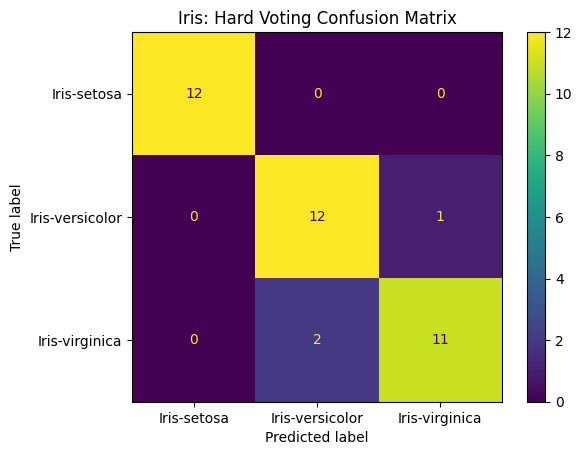

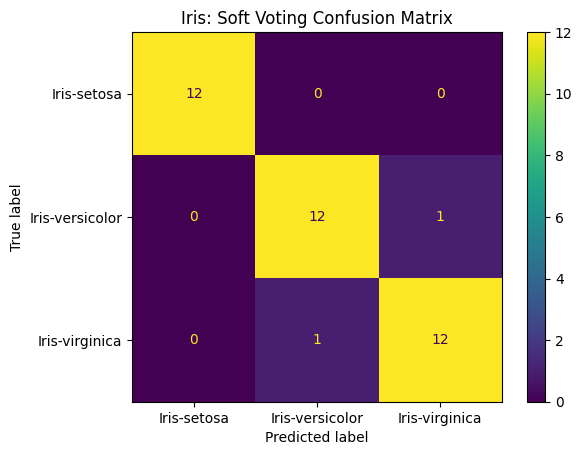

In [6]:
# --- Iris: hard vs soft voting (multi-class) ---
(X_iris, y_iris), iris_base_hard = build_classification_pipelines(df_iris, "classification", for_soft_voting=False)
(_, _), iris_base_soft = build_classification_pipelines(df_iris, "classification", for_soft_voting=True)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RNG)

print("Base models (hard-capable):")
for name in ["lr", "knn", "tree", "rf", "svc"]:
    m, s = eval_acc(iris_base_hard[name], X_iris, y_iris, cv)
    print(f"{name:>4}  acc={m:.3f} ± {s:.3f}")

hard_vote_iris = VotingClassifier(
    estimators=[
        ("lr", iris_base_hard["lr"]),
        ("knn", iris_base_hard["knn"]),
        ("tree", iris_base_hard["tree"]),
        ("rf", iris_base_hard["rf"]),
        ("svc", iris_base_hard["svc"]),
    ],
    voting="hard"
)

soft_vote_iris = VotingClassifier(
    estimators=[
        ("lr", iris_base_soft["lr"]),
        ("knn", iris_base_soft["knn"]),
        ("rf", iris_base_soft["rf"]),
        ("svc", iris_base_soft["svc"]),
    ],
    voting="soft",
    weights=[1, 1, 2, 1]
)

m, s = eval_acc(hard_vote_iris, X_iris, y_iris, cv)
print(f"hard_vote  acc={m:.3f} ± {s:.3f}")
m, s = eval_acc(soft_vote_iris, X_iris, y_iris, cv)
print(f"soft_vote  acc={m:.3f} ± {s:.3f}")

show_cm(hard_vote_iris, X_iris, y_iris, "Iris: Hard Voting Confusion Matrix")
show_cm(soft_vote_iris, X_iris, y_iris, "Iris: Soft Voting Confusion Matrix")


### ۳.۳ مطالعهٔ موردی: Diabetes (دودویی) — accuracy کافی نیست

در بسیاری از مسائل دودویی، accuracy می‌تواند مصالحه‌های مهم را پنهان کند (آستانه‌گذاری، عدم‌توازن، هزینه‌های نامتقارن).
Soft Voting وقتی بسیار مفید می‌شود که به **نمرهٔ ریسک** و **کیفیت رتبه‌بندی** نیاز دارید (مثلاً با ROC-AUC).

این مطالعهٔ موردی شامل:

- مقایسهٔ Hard و Soft
- مقایسهٔ AUC
- منحنی‌های کالیبراسیون
- منحنی‌های ROC با احتمال‌های cross-validated

**نکتهٔ مهم**: ROC-AUC به احتمال یا نمرهٔ تصمیم نیاز دارد؛ این هم یکی از دلایل اهمیت Soft Voting است.

---


In [7]:
# --- Diabetes: accuracy + ROC-AUC + calibration ---
(X_dia, y_dia), dia_base_hard = build_classification_pipelines(df_diabetes, "classification", for_soft_voting=False)
(_, _), dia_base_soft = build_classification_pipelines(df_diabetes, "classification", for_soft_voting=True)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RNG)

print("Base models (accuracy):")
for name in ["lr", "knn", "tree", "rf", "svc"]:
    m, s = eval_acc(dia_base_hard[name], X_dia, y_dia, cv)
    print(f"{name:>4}  acc={m:.3f} ± {s:.3f}")

hard_vote_dia = VotingClassifier(
    estimators=[
        ("lr", dia_base_hard["lr"]),
        ("knn", dia_base_hard["knn"]),
        ("rf", dia_base_hard["rf"]),
        ("svc", dia_base_hard["svc"]),
    ],
    voting="hard"
)

soft_vote_dia = VotingClassifier(
    estimators=[
        ("lr", dia_base_soft["lr"]),
        ("knn", dia_base_soft["knn"]),
        ("rf", dia_base_soft["rf"]),
        ("svc", dia_base_soft["svc"]),
    ],
    voting="soft"
)

# Calibrate SVC explicitly and then soft-vote
svc_cal = CalibratedClassifierCV(dia_base_hard["svc"], method="sigmoid", cv=3)

soft_vote_cal_dia = VotingClassifier(
    estimators=[
        ("lr", dia_base_soft["lr"]),
        ("rf", dia_base_soft["rf"]),
        ("svc_cal", svc_cal),
    ],
    voting="soft",
    weights=[1, 2, 1]
)

for name, model in [("hard_vote", hard_vote_dia), ("soft_vote", soft_vote_dia), ("soft_vote_cal", soft_vote_cal_dia)]:
    m, s = eval_acc(model, X_dia, y_dia, cv)
    print(f"{name:>12}  acc={m:.3f} ± {s:.3f}")

# ROC-AUC (binary) is often more informative than accuracy
pos_label = "Diabetic" if "Diabetic" in set(y_dia) else sorted(pd.unique(y_dia))[-1]
for name, model in [("lr", dia_base_soft["lr"]), ("rf", dia_base_soft["rf"]), ("soft_vote", soft_vote_dia), ("soft_vote_cal", soft_vote_cal_dia)]:
    auc = eval_auc_binary(model, X_dia, y_dia, cv, pos_label=pos_label)
    print(f"{name:>12}  roc_auc={auc:.3f}  (pos_label={pos_label})")


Base models (accuracy):
  lr  acc=0.775 ± 0.015
 knn  acc=0.749 ± 0.017
tree  acc=0.711 ± 0.056
  rf  acc=0.760 ± 0.030
 svc  acc=0.750 ± 0.020
   hard_vote  acc=0.758 ± 0.018
   soft_vote  acc=0.762 ± 0.019
soft_vote_cal  acc=0.764 ± 0.023
          lr  roc_auc=0.828  (pos_label=Diabetic)
          rf  roc_auc=0.825  (pos_label=Diabetic)
   soft_vote  roc_auc=0.830  (pos_label=Diabetic)
soft_vote_cal  roc_auc=0.834  (pos_label=Diabetic)


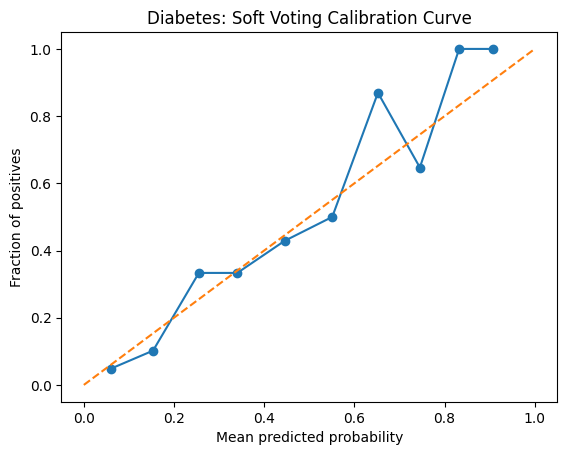

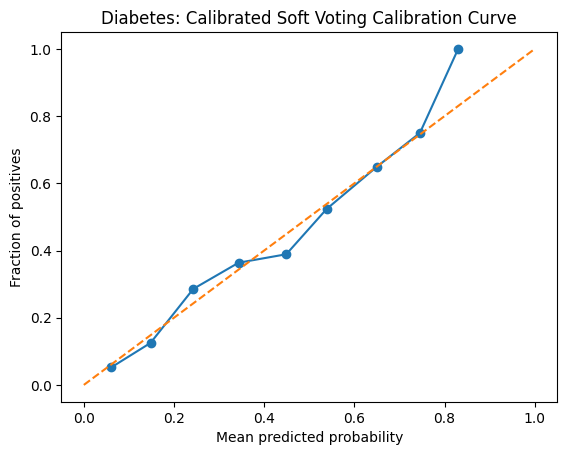

In [8]:
def plot_calibration(model, X, y, title, pos_label=None):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=RNG, stratify=y
    )
    model.fit(X_train, y_train)

    classes = list(model.classes_)
    if pos_label is None:
        pos_label = classes[-1]
    proba = model.predict_proba(X_test)[:, classes.index(pos_label)]
    y01 = (y_test == pos_label).astype(int)

    frac_pos, mean_pred = calibration_curve(y01, proba, n_bins=10, strategy="uniform")

    plt.figure()
    plt.plot(mean_pred, frac_pos, marker="o")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("Mean predicted probability")
    plt.ylabel("Fraction of positives")
    plt.title(title)
    plt.show()

plot_calibration(soft_vote_dia, X_dia, y_dia, "Diabetes: Soft Voting Calibration Curve", pos_label=pos_label)
plot_calibration(soft_vote_cal_dia, X_dia, y_dia, "Diabetes: Calibrated Soft Voting Calibration Curve", pos_label=pos_label)


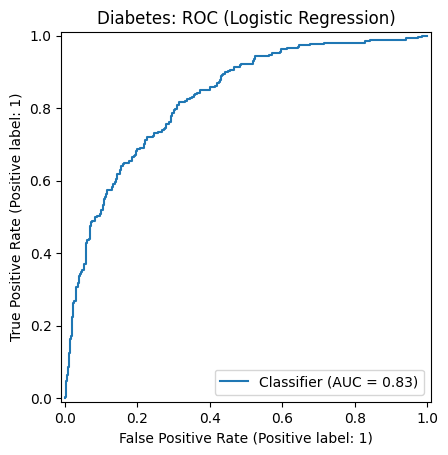

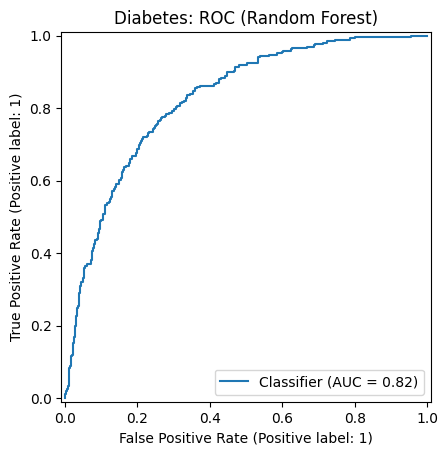

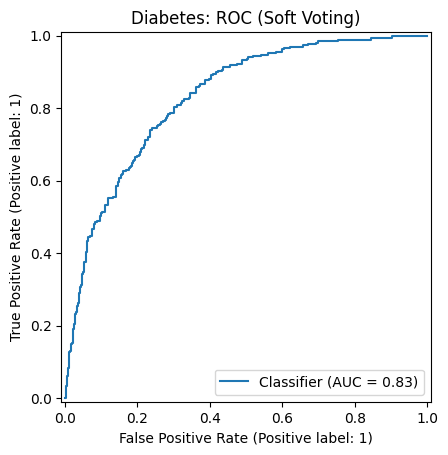

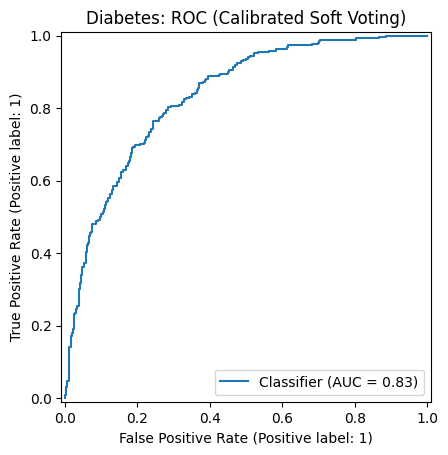

In [9]:
def plot_roc_cv(model, X, y, title, pos_label=None):
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RNG)
    model.fit(X, y)
    classes = list(model.classes_)
    if pos_label is None:
        pos_label = classes[-1]
    idx = classes.index(pos_label)

    proba = cross_val_predict(model, X, y, cv=cv, method="predict_proba")[:, idx]
    y01 = (y == pos_label).astype(int)

    RocCurveDisplay.from_predictions(y01, proba)
    plt.title(title)
    plt.show()

plot_roc_cv(dia_base_soft["lr"], X_dia, y_dia, "Diabetes: ROC (Logistic Regression)", pos_label=pos_label)
plot_roc_cv(dia_base_soft["rf"], X_dia, y_dia, "Diabetes: ROC (Random Forest)", pos_label=pos_label)
plot_roc_cv(soft_vote_dia, X_dia, y_dia, "Diabetes: ROC (Soft Voting)", pos_label=pos_label)
plot_roc_cv(soft_vote_cal_dia, X_dia, y_dia, "Diabetes: ROC (Calibrated Soft Voting)", pos_label=pos_label)


### ۳.۴ مطالعهٔ موردی: Drug200 (ویژگی‌های عمدتاً رده‌ای)

این دیتاست یک تست فشار خوب برای داده‌های جدولی واقعی است چون چندین ویژگی رده‌ای دارد:
`Sex`، `BP`، `Cholesterol`.

نکات کلیدی:

- بدون Pipeline، مدیریت دسته‌ها مستعد خطاست.
- One-hot بُعد را زیاد می‌کند؛ مدل‌های خطی ممکن است سود ببرند، اما مدل‌های مبتنی بر فاصله (مثل kNN) ممکن است افت کنند.
- تجمیع‌ها اغلب کمک می‌کنند چون مدل‌های مختلف واکنش‌های متفاوتی به فضای sparse و پر‌بُعد دارند.

---


In [10]:
# --- Drug200: mostly categorical features ---
(X_drug, y_drug), drug_base_hard = build_classification_pipelines(df_drug, "Drug", for_soft_voting=False)
(_, _), drug_base_soft = build_classification_pipelines(df_drug, "Drug", for_soft_voting=True)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RNG)

print("Drug200 base models:")
for name in ["lr", "knn", "tree", "rf", "svc"]:
    m, s = eval_acc(drug_base_hard[name], X_drug, y_drug, cv)
    print(f"{name:>4}  acc={m:.3f} ± {s:.3f}")

hard_vote_drug = VotingClassifier(
    estimators=[
        ("lr", drug_base_hard["lr"]),
        ("knn", drug_base_hard["knn"]),
        ("tree", drug_base_hard["tree"]),
        ("rf", drug_base_hard["rf"]),
        ("svc", drug_base_hard["svc"]),
    ],
    voting="hard"
)

soft_vote_drug = VotingClassifier(
    estimators=[
        ("lr", drug_base_soft["lr"]),
        ("knn", drug_base_soft["knn"]),
        ("rf", drug_base_soft["rf"]),
        ("svc", drug_base_soft["svc"]),
    ],
    voting="soft",
    weights=[1, 1, 2, 1]
)

m, s = eval_acc(hard_vote_drug, X_drug, y_drug, cv)
print(f"hard_vote  acc={m:.3f} ± {s:.3f}")
m, s = eval_acc(soft_vote_drug, X_drug, y_drug, cv)
print(f"soft_vote  acc={m:.3f} ± {s:.3f}")


Drug200 base models:
  lr  acc=0.955 ± 0.033
 knn  acc=0.900 ± 0.022
tree  acc=0.990 ± 0.012
  rf  acc=0.990 ± 0.012
 svc  acc=0.970 ± 0.019
hard_vote  acc=0.980 ± 0.019
soft_vote  acc=0.990 ± 0.012


### ۳.۵ مطالعهٔ موردی: Wine quality — تبدیل برچسب رگرسیونی به تصمیم طبقه‌بندی

در `Wine_Quality.csv` یک امتیاز صحیح `quality` داریم. در بسیاری از محصولات، چنین امتیازی را به یک تصمیم عملی تبدیل می‌کنند:

- “good” اگر quality ≥ 7
- “not_good” در غیر این صورت

این الگو در سیستم‌های کیفیت/ریسک رایج است: یک مقدار پیوسته به یک اقدام گسسته منجر می‌شود.
VotingClassifierها اغلب در همین لایهٔ تصمیم مستقر می‌شوند.

در این مطالعهٔ موردی:

- یک برچسب دودویی مشتق‌شده می‌سازیم
- Hard و Soft Voting را آموزش می‌دهیم
- هم accuracy و هم ROC-AUC را ارزیابی می‌کنیم

---


hard_vote  acc=0.841 ± 0.008
soft_vote  acc=0.843 ± 0.007
soft_vote roc_auc: 0.8863588543561406


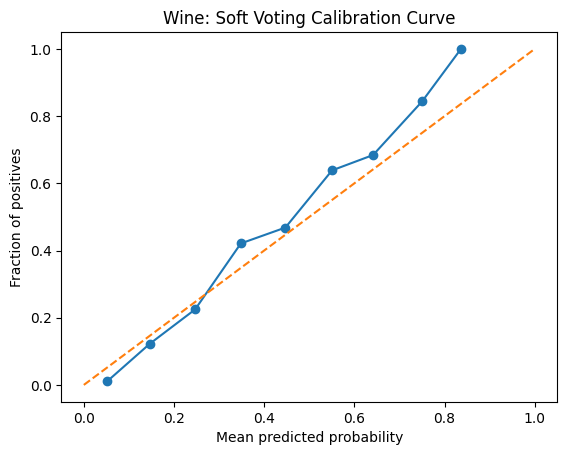

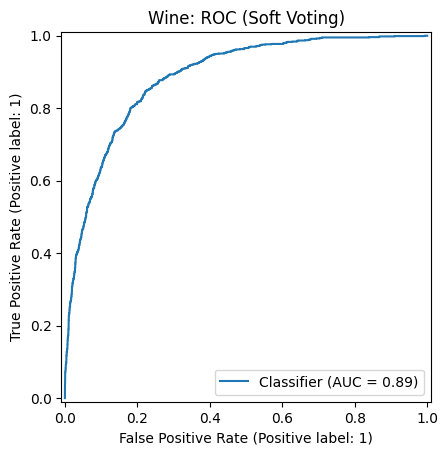

In [11]:
# --- Wine quality: convert to binary classification and vote ---
df_wine_bin = df_wine.copy()
df_wine_bin["label"] = np.where(df_wine_bin["quality"] >= 7, "good", "not_good")
df_wine_bin = df_wine_bin.drop(columns=["quality"])

(X_wine, y_wine), wine_base_hard = build_classification_pipelines(df_wine_bin, "label", for_soft_voting=False)
(_, _), wine_base_soft = build_classification_pipelines(df_wine_bin, "label", for_soft_voting=True)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RNG)

hard_vote_wine = VotingClassifier(
    estimators=[
        ("lr", wine_base_hard["lr"]),
        ("knn", wine_base_hard["knn"]),
        ("rf", wine_base_hard["rf"]),
        ("svc", wine_base_hard["svc"]),
    ],
    voting="hard"
)

soft_vote_wine = VotingClassifier(
    estimators=[
        ("lr", wine_base_soft["lr"]),
        ("knn", wine_base_soft["knn"]),
        ("rf", wine_base_soft["rf"]),
        ("svc", wine_base_soft["svc"]),
    ],
    voting="soft"
)

for name, model in [("hard_vote", hard_vote_wine), ("soft_vote", soft_vote_wine)]:
    m, s = eval_acc(model, X_wine, y_wine, cv)
    print(f"{name:>9}  acc={m:.3f} ± {s:.3f}")

pos_label = "good"
auc_soft = eval_auc_binary(soft_vote_wine, X_wine, y_wine, cv, pos_label=pos_label)
print("soft_vote roc_auc:", auc_soft)

plot_calibration(soft_vote_wine, X_wine, y_wine, "Wine: Soft Voting Calibration Curve", pos_label=pos_label)
plot_roc_cv(soft_vote_wine, X_wine, y_wine, "Wine: ROC (Soft Voting)", pos_label=pos_label)


## ۴) تشخیص علت بهبود/عدم بهبود تجمیع: تنوع + شایستگی

یک سؤال رایج: *چرا Voting من بهتر شد (یا نشد)؟*

دو بعد به طور هم‌زمان مهم‌اند:

1. **شایستگی (competence)**: مدل‌های پایه باید از baselineهای ساده واقعاً بهتر باشند.
2. **تنوع (diversity)**: مدل‌های پایه باید اشتباهات *متفاوت* انجام دهند.

ممکن است این حالات را ببینید:

- شایستگی بالا + تنوع کم → سود کم (مدل‌ها زائد)
- شایستگی کم + تنوع بالا → همچنان ضعیف (راه‌های مختلف برای اشتباه)
- شایستگی بالا + تنوع بالا → بهترین حالت (موفقیت معمول تجمیع)

در ادامه دو ماتریس تنوع را روی یک split تشخیصی محاسبه می‌کنیم:

- نرخ عدم‌توافق
- Q-statistic

سپس می‌توانید تشخیص دهید کدام مدل‌ها زائد هستند.

---


In [12]:
# --- Diversity diagnostics: disagreement + Q-statistic on a holdout split ---
from itertools import combinations

def confusion_counts(y_true, y_pred):
    correct = (y_pred == y_true)
    return correct.astype(int)

def disagreement_rate(pred_a, pred_b):
    return np.mean(pred_a != pred_b)

def q_statistic(y_true, pred_a, pred_b):
    # N11 both correct, N00 both wrong, N10 A correct B wrong, N01 A wrong B correct
    ca = (pred_a == y_true)
    cb = (pred_b == y_true)
    N11 = np.sum(ca & cb)
    N00 = np.sum(~ca & ~cb)
    N10 = np.sum(ca & ~cb)
    N01 = np.sum(~ca & cb)
    denom = (N11 * N00 + N10 * N01)
    if denom == 0:
        return np.nan
    return (N11 * N00 - N10 * N01) / denom

def diversity_report(models, X, y, title):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=RNG, stratify=y
    )
    preds = {}
    for name, model in models.items():
        model.fit(X_train, y_train)
        preds[name] = model.predict(X_test)

    names = list(models.keys())
    dis = pd.DataFrame(index=names, columns=names, dtype=float)
    q = pd.DataFrame(index=names, columns=names, dtype=float)

    for a in names:
        for b in names:
            dis.loc[a, b] = disagreement_rate(preds[a], preds[b])
            q.loc[a, b] = q_statistic(y_test.values if hasattr(y_test, "values") else y_test, preds[a], preds[b])

    print(title)
    display(dis)
    display(q)

# Example: Diabetes base learners
diag_models = {
    "lr": dia_base_hard["lr"],
    "knn": dia_base_hard["knn"],
    "rf": dia_base_hard["rf"],
    "svc": dia_base_hard["svc"],
}

diversity_report(diag_models, X_dia, y_dia, "Diversity report (Diabetes)")


Diversity report (Diabetes)


,lr,knn,rf,svc
lr,0.000000,0.129870,0.121212,0.090909
knn,0.129870,0.000000,0.129870,0.125541
rf,0.121212,0.129870,0.000000,0.108225
svc,0.090909,0.125541,0.108225,0.000000


,lr,knn,rf,svc
lr,1.000000,0.933884,0.944237,0.971448
knn,0.933884,1.000000,0.934811,0.939394
rf,0.944237,0.934811,1.000000,0.957166
svc,0.971448,0.939394,0.957166,1.000000


## ۵) رگرسیون: میانگین‌گیری، وزن‌دهی، و تجمیع مقاوم

Voting در رگرسیون همان *میانگین‌گیری* است. سؤال‌های کلیدی:

1. کدام رگرسورها را میانگین بگیریم؟
2. آیا وزن بدهیم (و چگونه از leakage جلوگیری کنیم)؟
3. اگر یکی از مدل‌ها گاهی خطاهای بسیار بزرگ بدهد چه کنیم؟

### ۵.۱ رگرسورهای پایه (بایاس‌های القایی متنوع)

سه رگرسور استفاده می‌کنیم:

- **Ridge**: baseline خطی پایدار (واریانس کم).
- **RandomForestRegressor**: غیرخطی و مناسب تعامل ویژگی‌ها (واریانس بالاتر).
- **GradientBoostingRegressor**: تقریب‌زنندهٔ غیرخطی قوی (حساس به تنظیم).

### ۵.۲ انتخاب وزن با Cross-Validation

یک ابتکار عملی وزن‌دهی معکوس RMSE است:

$$w_m \propto \frac{1}{\text{RMSE}_m + \epsilon}$$

این روش برای هر loss بهینه نیست، اما نقطهٔ شروع قابل دفاعی است و اغلب از وزن‌های برابر بهتر است.

### ۵.۳ گزینه‌های مقاوم‌تر از میانگین

میانگین حسابی به پیش‌بینی‌های پرت حساس است.
دو تجمیع‌گر مقاوم:

- **میانه (median)** پیش‌بینی‌ها
- **میانگین برش‌خورده (trimmed mean)** (حذف درصدی از بالا/پایین در هر نمونه)

این‌ها وقتی مفیدند که یک مدل گاهی «منفجر» شود و خطاهای بزرگ بدهد.

### ۵.۴ یک نشانهٔ سادهٔ عدم‌قطعیت

حتی بدون مدل‌های بیزی، **پراکندگی** پیش‌بینی‌های مدل‌های پایه می‌تواند یک سیگنال عدم‌قطعیت باشد.
برای هر نمونه $x$ می‌توانید صدک‌ها را بین مدل‌ها محاسبه کنید (مثلاً ۱۰٪ و ۹۰٪). این یک بازهٔ کالیبره نیست، اما برای triage مفید است.

---


In [13]:
# --- Load regression datasets (repo paths) ---
house_path = DATA_ROOT / "Regression" / "house-prices.csv"
diamonds_path = DATA_ROOT / "Regression" / "diamonds.csv"
salaries_path = DATA_ROOT / "Regression" / "salaries.csv"

house_fallback = """Home,Price,SqFt,Bedrooms,Bathrooms,Offers,Brick,Neighborhood
1,114300,1790,2,2,2,No,East
2,114200,2030,4,2,3,No,East
3,114800,1740,3,2,1,No,East
4,94700,1980,3,2,3,No,East
5,119800,2130,3,3,3,No,East
"""

diamonds_fallback = """id,carat,cut,color,clarity,depth,table,price,x,y,z
1,0.23,Ideal,E,SI2,61.5,55,326,3.95,3.98,2.43
2,0.21,Premium,E,SI1,59.8,61,326,3.89,3.84,2.31
3,0.23,Good,E,VS1,56.9,65,327,4.05,4.07,2.31
4,0.29,Premium,I,VS2,62.4,58,334,4.2,4.23,2.63
5,0.31,Good,J,SI2,63.3,58,335,4.34,4.35,2.75
"""

salaries_fallback = """Name,Age,Job,Salary
Kevin Sanders,24,Software Engineer,7300
Lisa Mills,26,High School Teacher,6100
Donna Allison,27,Dentist,12700
Michael Schmitt,43,Dentist,17500
Lisa Shaffer,31,Accountant,7400
"""

df_house = read_csv_or_fallback(house_path, house_fallback)
df_diamonds = read_csv_or_fallback(diamonds_path, diamonds_fallback)
df_salaries = read_csv_or_fallback(salaries_path, salaries_fallback)

print("House prices:"); peek(df_house)
print("Diamonds:"); peek(df_diamonds)
print("Salaries:"); peek(df_salaries)


Loaded: ..\..\..\Datasets\Regression\house-prices.csv  shape=(128, 8)
Loaded: ..\..\..\Datasets\Regression\diamonds.csv  shape=(53940, 11)
Loaded: ..\..\..\Datasets\Regression\salaries.csv  shape=(1000, 4)
House prices:


,Home,Price,SqFt,Bedrooms,Bathrooms,Offers,Brick,Neighborhood
0,1,114300,1790,2,2,2,No,East
1,2,114200,2030,4,2,3,No,East
2,3,114800,1740,3,2,1,No,East
3,4,94700,1980,3,2,3,No,East
4,5,119800,2130,3,3,3,No,East


shape: (128, 8)
Diamonds:


,id,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


shape: (53940, 11)
Salaries:


,Name,Age,Job,Salary
0,Kevin Sanders,24,Software Engineer,7300
1,Lisa Mills,26,High School Teacher,6100
2,Donna Allison,27,Dentist,12700
3,Michael Schmitt,43,Dentist,17500
4,Lisa Shaffer,31,Accountant,7400


shape: (1000, 4)


In [14]:
def build_regression_pipelines(df: pd.DataFrame, target_col: str):
    X = df.drop(columns=[target_col])
    y = df[target_col]

    num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = [c for c in X.columns if c not in num_cols]

    numeric_tf = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])

    categorical_tf = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])

    pre = ColumnTransformer(
        transformers=[
            ("num", numeric_tf, num_cols),
            ("cat", categorical_tf, cat_cols),
        ],
        remainder="drop"
    )

    ridge = Pipeline(steps=[("pre", pre), ("reg", Ridge(alpha=1.0, random_state=RNG))])
    rf = Pipeline(steps=[("pre", pre), ("reg", RandomForestRegressor(n_estimators=500, random_state=RNG, n_jobs=-1, min_samples_leaf=2))])
    gbr = Pipeline(steps=[("pre", pre), ("reg", GradientBoostingRegressor(random_state=RNG))])

    return (X, y), {"ridge": ridge, "rf": rf, "gbr": gbr}

def eval_reg(model, X, y, cv):
    rmse = -cross_val_score(model, X, y, cv=cv, scoring="neg_root_mean_squared_error").mean()
    mae = -cross_val_score(model, X, y, cv=cv, scoring="neg_mean_absolute_error").mean()
    r2 = cross_val_score(model, X, y, cv=cv, scoring="r2").mean()
    return rmse, mae, r2


In [15]:
# --- Regression: VotingRegressor + robust alternatives ---
(X_house, y_house), house_regs = build_regression_pipelines(df_house, "Price")
(X_diam, y_diam), diam_regs = build_regression_pipelines(df_diamonds, "price")

cv = KFold(n_splits=5, shuffle=True, random_state=RNG)

print("House base regressors:")
for name, model in house_regs.items():
    rmse, mae, r2 = eval_reg(model, X_house, y_house, cv)
    print(f"{name:>5}  rmse={rmse:.2f}  mae={mae:.2f}  r2={r2:.3f}")

vote_house = VotingRegressor(
    estimators=[("ridge", house_regs["ridge"]), ("rf", house_regs["rf"]), ("gbr", house_regs["gbr"])],
    weights=[1, 2, 2]
)
rmse, mae, r2 = eval_reg(vote_house, X_house, y_house, cv)
print(f"{'vote':>5}  rmse={rmse:.2f}  mae={mae:.2f}  r2={r2:.3f}")

print("\nDiamonds base regressors:")
for name, model in diam_regs.items():
    rmse, mae, r2 = eval_reg(model, X_diam, y_diam, cv)
    print(f"{name:>5}  rmse={rmse:.2f}  mae={mae:.2f}  r2={r2:.3f}")

vote_diam = VotingRegressor(
    estimators=[("ridge", diam_regs["ridge"]), ("rf", diam_regs["rf"]), ("gbr", diam_regs["gbr"])]
)
rmse, mae, r2 = eval_reg(vote_diam, X_diam, y_diam, cv)
print(f"{'vote':>5}  rmse={rmse:.2f}  mae={mae:.2f}  r2={r2:.3f}")


House base regressors:
ridge  rmse=9984.70  mae=7765.01  r2=0.828
   rf  rmse=12701.20  mae=9763.38  r2=0.733
  gbr  rmse=13029.78  mae=9660.42  r2=0.720
 vote  rmse=11769.65  mae=8983.01  r2=0.770

Diamonds base regressors:
ridge  rmse=1128.41  mae=741.46  r2=0.920
   rf  rmse=32.93  mae=3.50  r2=1.000
  gbr  rmse=219.40  mae=134.12  r2=0.997
 vote  rmse=399.56  mae=257.67  r2=0.990


In [16]:
def inv_rmse_weights(models_dict, X, y, cv, eps=1e-6):
    rmses = {}
    for name, model in models_dict.items():
        rmse = -cross_val_score(model, X, y, cv=cv, scoring="neg_root_mean_squared_error").mean()
        rmses[name] = rmse
    inv = {k: 1.0 / (v + eps) for k, v in rmses.items()}
    ssum = sum(inv.values())
    w = {k: inv[k] / ssum for k in inv}
    return rmses, w

rmses, w = inv_rmse_weights(diam_regs, X_diam, y_diam, cv)
print("RMSE:", rmses)
print("weights:", w)

vote_diam_w = VotingRegressor(
    estimators=[("ridge", diam_regs["ridge"]), ("rf", diam_regs["rf"]), ("gbr", diam_regs["gbr"])],
    weights=[w["ridge"], w["rf"], w["gbr"]]
)
rmse, mae, r2 = eval_reg(vote_diam_w, X_diam, y_diam, cv)
print(f"weighted vote  rmse={rmse:.2f}  mae={mae:.2f}  r2={r2:.3f}")


RMSE: {'ridge': np.float64(1128.4115763978705), 'rf': np.float64(32.92626045944767), 'gbr': np.float64(219.3974382262319)}
weights: {'ridge': np.float64(0.02474384006737511), 'rf': np.float64(0.847992889678516), 'gbr': np.float64(0.12726327025410888)}
weighted vote  rmse=53.64  mae=29.07  r2=1.000


In [17]:
# --- Robust averaging: median and trimmed-mean ensembles ---
def fit_predict(model, X_train, X_test, y_train):
    model.fit(X_train, y_train)
    return model.predict(X_test)

def median_ensemble_predict(models, X_train, X_test, y_train):
    preds = np.column_stack([fit_predict(m, X_train, X_test, y_train) for m in models])
    return np.median(preds, axis=1)

def trimmed_mean_predict(models, X_train, X_test, y_train, trim=0.2):
    preds = np.column_stack([fit_predict(m, X_train, X_test, y_train) for m in models])
    preds_sorted = np.sort(preds, axis=1)
    k = int(trim * preds.shape[1])
    if 2*k >= preds.shape[1]:
        k = 0
    trimmed = preds_sorted[:, k:preds.shape[1]-k]
    return trimmed.mean(axis=1)

# Demonstration on diamonds with a single split (diagnostic only)
X_train, X_test, y_train, y_test = train_test_split(X_diam, y_diam, test_size=0.25, random_state=RNG)

models = [diam_regs["ridge"], diam_regs["rf"], diam_regs["gbr"]]
pred_mean = vote_diam.fit(X_train, y_train).predict(X_test)  # mean by default
pred_med = median_ensemble_predict(models, X_train, X_test, y_train)
pred_trim = trimmed_mean_predict(models, X_train, X_test, y_train, trim=0.2)

def rmse(y_true, y_pred):
    return mean_squared_error(y_true, y_pred, squared=False)

print("RMSE mean :", rmse(y_test, pred_mean))
print("RMSE median:", rmse(y_test, pred_med))
print("RMSE trim :", rmse(y_test, pred_trim))


RMSE mean : 398.53940463997645
RMSE median: 159.93099742875694
RMSE trim : 398.53940463997645


C:\Users\LENOVO.PIESC\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\LENOVO.PIESC\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\LENOVO.PIESC\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [18]:
# --- Simple uncertainty proxy: prediction spread across base models ---
# NOTE: This is not a calibrated predictive interval, but a useful heuristic for triage.
models = [diam_regs["ridge"], diam_regs["rf"], diam_regs["gbr"]]

X_train, X_test, y_train, y_test = train_test_split(X_diam, y_diam, test_size=0.25, random_state=RNG)

preds = []
for m in models:
    m.fit(X_train, y_train)
    preds.append(m.predict(X_test))
preds = np.column_stack(preds)

pred_mean = preds.mean(axis=1)
lo = np.quantile(preds, 0.10, axis=1)
hi = np.quantile(preds, 0.90, axis=1)

df_pi = pd.DataFrame({"y_true": y_test.values, "pred_mean": pred_mean, "p10": lo, "p90": hi})
df_pi.head(10)


,y_true,pred_mean,p10,p90
0,559,561.892092,514.238670,612.090079
1,2201,2523.511043,2094.861559,3081.345220
2,1238,1450.786154,1157.016164,1829.658206
3,1304,1551.068390,1242.842089,1957.857085
4,6901,7838.664661,6776.499394,9276.501014
5,3011,3466.798169,3123.925187,3770.961711
6,1765,1985.573791,1741.862264,2317.314875
7,1679,1975.627489,1699.882910,2327.681444
8,2102,2415.309084,2118.158304,2805.580915
9,4789,5369.832027,4864.197051,5957.043704


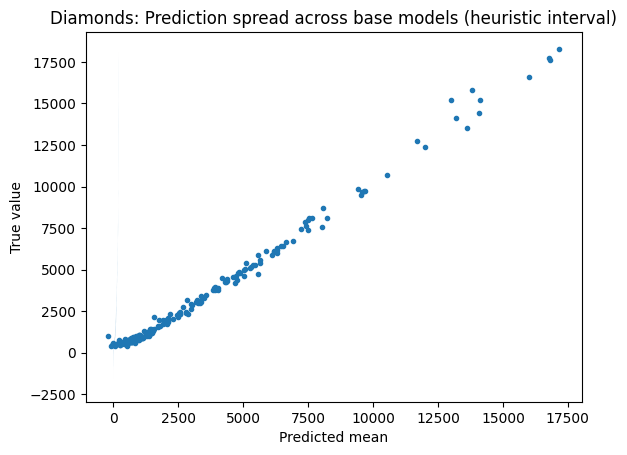

In [19]:
# Plot predicted mean vs true with a subset of points and interval bands
sub = df_pi.sample(n=min(200, len(df_pi)), random_state=RNG).sort_values("pred_mean")
plt.figure()
plt.plot(sub["pred_mean"].values, sub["y_true"].values, marker=".", linestyle="")
plt.fill_between(range(len(sub)), sub["p10"].values, sub["p90"].values, alpha=0.3)
plt.xlabel("Predicted mean")
plt.ylabel("True value")
plt.title("Diamonds: Prediction spread across base models (heuristic interval)")
plt.show()


## ۶) نگاه عمیق‌تر: رأی‌گیری به‌عنوان کمینه‌سازی ریسک

رأی‌گیری/میانگین‌گیری فقط یک شهود مثل «حکمت جمع» نیست؛ می‌توان آن را با **نظریهٔ تصمیم** هم توجیه کرد.

### ۶.۱ قاعدهٔ تصمیم بیز و دلیل اهمیت کالیبراسیون احتمال

در طبقه‌بندی $K$ کلاسه، فرض کنید توزیع شرطی واقعی $p^*(y=k\mid x)$ باشد.
اگر از **زیان ۰–۱** استفاده کنید، تصمیم بهینهٔ بیزی این است:

$$\hat{y}^*(x)=\arg\max_k\; p^*(y=k\mid x)$$

این رابطه در ظاهر ساده است، اما یک پیام کلیدی دارد:

> اگر احتمال‌های مدل شما خوب کالیبره باشد و به $p^*(\cdot\mid x)$ نزدیک باشد، انتخاب argmax تقریباً بهینه است.

Soft Voting تلاش می‌کند $p^*(\cdot\mid x)$ را با ترکیب چند توزیع تقریبی نزدیک کند:

$$\bar{p}(y=k\mid x) = \sum_{m=1}^{M} w_m\,p_m(y=k\mid x)$$

اگر هر $p_m$ نویزی باشد ولی سوگیری سیستماتیک یکسان نداشته باشد، میانگین‌گیری می‌تواند نویز را در فضای احتمال کاهش دهد.

### ۶.۲ Proper scoring ruleها (Log loss و Brier score)

اگر احتمال‌ها برایتان مهم است (نه فقط برچسب)، باید آن‌ها را با **proper scoring rule**ها ارزیابی کنید.
یک scoring rule «proper» است اگر کمینهٔ آن زمانی رخ دهد که شما توزیع واقعی را گزارش دهید.

دو مثال رایج:

1. **Log loss** (cross-entropy) برای مشاهدهٔ $(x_i,y_i)$:
   $$\ell_{\log}(p, y_i) = -\log p(y_i\mid x_i)$$

2. **Brier score** (حالت دودویی):
   $$\ell_{\text{Brier}}(p, y_i) = (p_i - y_i)^2$$

Soft Voting معمولاً log loss را بهتر می‌کند وقتی:
- مدل‌های پایه به‌تنهایی قابل‌قبول باشند
- خطاهایشان کاملاً هم‌بسته نباشد
- احتمال‌ها شدیداً بدکالیبره نباشند

اما اگر یک مدل **بیش‌ازحد مطمئن** باشد (احتمال‌های نزدیک ۰ یا ۱ اما اغلب غلط)، می‌تواند log loss تجمیع را خراب کند.
به همین دلیل است که کالیبراسیون (Platt scaling / isotonic regression) اغلب پیش‌نیاز Soft Voting است.

### ۶.۳ مرز مفهومی Soft Voting و Stacking

Soft Voting از وزن‌های **ثابت** استفاده می‌کند:
$$\bar{p}(\cdot\mid x)=\sum_m w_m p_m(\cdot\mid x)$$

Stacking یک **meta-model** $g$ را یاد می‌گیرد (اغلب logistic regression) که خروجی مدل‌های پایه را به یک خروجی ترکیبی تبدیل می‌کند:
$$\bar{p}(\cdot\mid x)=g\big(p_1(\cdot\mid x),\dots,p_M(\cdot\mid x)\big)$$

پس Stacking می‌تواند وزن‌های وابسته به زمینه یاد بگیرد (مثلاً در برخی نواحی فضای ویژگی بیشتر به یک مدل اعتماد کند).
Voting ساده‌تر، قابل ممیزی‌تر، و اغلب به‌طور شگفت‌انگیزی رقابتی است.

---


In [20]:
# --- Probability quality: compare Brier score on Diabetes ---
from sklearn.metrics import brier_score_loss

def brier_score_cv(model, X, y, pos_label):
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RNG)
    model.fit(X, y)
    classes = list(model.classes_)
    idx = classes.index(pos_label)
    proba = cross_val_predict(model, X, y, cv=cv, method="predict_proba")[:, idx]
    y01 = (y == pos_label).astype(int)
    return brier_score_loss(y01, proba)

pos_label = "Diabetic" if "Diabetic" in set(y_dia) else sorted(pd.unique(y_dia))[-1]
models = {
    "lr": dia_base_soft["lr"],
    "rf": dia_base_soft["rf"],
    "soft_vote": soft_vote_dia,
    "soft_vote_cal": soft_vote_cal_dia,
}

for name, m in models.items():
    bs = brier_score_cv(m, X_dia, y_dia, pos_label=pos_label)
    print(f"{name:>12}  brier={bs:.4f}")


          lr  brier=0.1580
          rf  brier=0.1608
   soft_vote  brier=0.1588
soft_vote_cal  brier=0.1569


### ۶.۴ انتخاب وزن‌ها: نگاه به‌صورت یک بهینه‌سازی مقید ساده

در Soft Voting دودویی، فرض کنید هر مدل احتمال کلاس مثبت را $p_m(x)$ بدهد.
احتمال تجمیع:

$$\bar{p}(x;w)=\sum_{m=1}^{M} w_m p_m(x),\quad w_m\ge 0,\ \sum_m w_m=1$$

یک راه اصولی برای انتخاب وزن‌ها کمینه کردن یک proper scoring rule روی دادهٔ اعتبارسنجی است.
مثلاً برای log loss روی مجموعهٔ اعتبارسنجی $\{(x_i,y_i)\}_{i=1}^n$:

$$\min_{w\in\Delta_M}\; \sum_{i=1}^{n} \left[-y_i\log \bar{p}(x_i;w) - (1-y_i)\log(1-\bar{p}(x_i;w))\right]$$

که در آن $\Delta_M$ ساده‌کس احتمال است.

این تابع هدف نسبت به $w$ **کوژ** است (چون منفیِ log کوژ است و $\bar{p}$ نسبت به $w$ خطی است)،
پس از نظر تئوری می‌توان آن را کارآمد حل کرد.

در عمل، بسیاری از تیم‌ها یک جایگزین سبک استفاده می‌کنند:
- جست‌وجوی یک grid کوچک از بردارهای وزن
- انتخاب بر اساس log loss یا ROC-AUC در Cross-Validation
- نگه داشتن وزن‌ها ساده برای قابلیت ممیزی

در ادامه یک grid search کوچک روی وزن‌ها برای دیتاست diabetes بر اساس ROC-AUC پیاده‌سازی می‌کنیم.

---


In [21]:
# --- Small grid search over soft-voting weights (Diabetes) ---
# We search weights for (lr, rf, svc_cal) on the simplex w1+w2+w3=1.
# Keep grid small to stay fast; increase step resolution for better search.
from itertools import product

def soft_vote_with_weights(w_lr, w_rf, w_svc):
    return VotingClassifier(
        estimators=[
            ("lr", dia_base_soft["lr"]),
            ("rf", dia_base_soft["rf"]),
            ("svc_cal", svc_cal),
        ],
        voting="soft",
        weights=[w_lr, w_rf, w_svc]
    )

pos_label = "Diabetic" if "Diabetic" in set(y_dia) else sorted(pd.unique(y_dia))[-1]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RNG)

best = (-np.inf, None)
step = 0.25  # try 0.1 for finer search (slower)
grid = np.arange(0.0, 1.0 + 1e-9, step)

for w_lr in grid:
    for w_rf in grid:
        w_svc = 1.0 - w_lr - w_rf
        if w_svc < -1e-9:
            continue
        if w_svc < 0:
            w_svc = 0.0  # numerical
        model = soft_vote_with_weights(w_lr, w_rf, w_svc)
        auc = eval_auc_binary(model, X_dia, y_dia, cv, pos_label=pos_label)
        if auc > best[0]:
            best = (auc, (w_lr, w_rf, w_svc))

print("Best ROC-AUC:", best[0])
print("Best weights (lr, rf, svc_cal):", best[1])


Best ROC-AUC: 0.8357313432835821
Best weights (lr, rf, svc_cal): (np.float64(0.5), np.float64(0.5), np.float64(0.0))


### ۶.۵ آستانه‌گذاری: تبدیل احتمال به تصمیم (نگاه هزینه‌محور)

Soft Voting احتمال $\bar{p}(y=1\mid x)$ را به شما می‌دهد.
برای تبدیل این احتمال به تصمیم، یک **آستانه** $t$ تعیین می‌کنید:

$$\hat{y}(x)=\mathbf{1}\{\bar{p}(y=1\mid x)\ge t\}$$

آستانهٔ پیش‌فرض $t=0.5$ فقط تحت فرض‌های خاص بهینه است (اولویت‌های برابر، هزینه‌های برابر).
اگر هزینهٔ false negative بیشتر از false positive باشد، باید آستانه را پایین‌تر بیاورید.

اگر هزینهٔ FN برابر $C_{FN}$ و هزینهٔ FP برابر $C_{FP}$ باشد، آستانهٔ بهینه (دودویی) تحت کمینه‌سازی هزینهٔ مورد انتظار:

$$t^* = \frac{C_{FP}}{C_{FP}+C_{FN}}$$

این رابطه احتمال‌محور بودن را به تصمیم‌گیری متصل می‌کند.
در عمل، تیم‌ها $t$ را با بیشینه کردن یک متریک هدف (F1، recall در precision ثابت، utility) تنظیم می‌کنند.

در ادامه یک sweep سادهٔ آستانه را نشان می‌دهیم که F1 را برای diabetes با احتمال‌های cross-validated بیشینه می‌کند.

---


Best F1: 0.6830870279146142 at threshold: 0.35


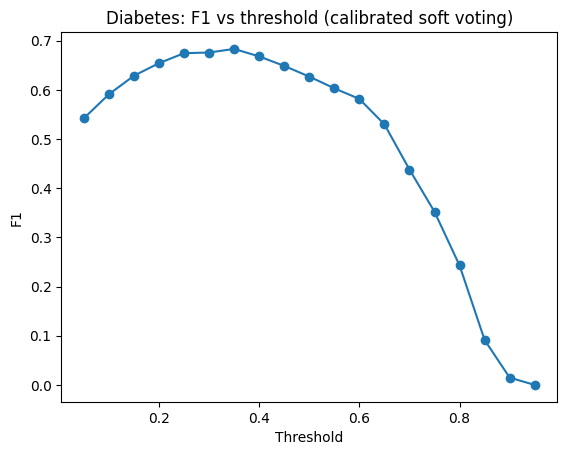

In [22]:
# --- Threshold tuning (Diabetes): maximize F1 over a grid ---
pos_label = "Diabetic" if "Diabetic" in set(y_dia) else sorted(pd.unique(y_dia))[-1]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RNG)

model = soft_vote_cal_dia  # use calibrated soft voting
model.fit(X_dia, y_dia)
classes = list(model.classes_)
idx = classes.index(pos_label)

proba = cross_val_predict(model, X_dia, y_dia, cv=cv, method="predict_proba")[:, idx]
y01 = (y_dia == pos_label).astype(int).values

ths = np.linspace(0.05, 0.95, 19)
best = (-1, None)
for t in ths:
    pred = (proba >= t).astype(int)
    f1 = f1_score(y01, pred)
    if f1 > best[0]:
        best = (f1, t)

print("Best F1:", best[0], "at threshold:", best[1])

# Plot F1 vs threshold
f1s = []
for t in ths:
    pred = (proba >= t).astype(int)
    f1s.append(f1_score(y01, pred))

plt.figure()
plt.plot(ths, f1s, marker="o")
plt.xlabel("Threshold")
plt.ylabel("F1")
plt.title("Diabetes: F1 vs threshold (calibrated soft voting)")
plt.show()


## ۷) دیدگاه بایاس–واریانس: چرا میانگین‌گیری MSE را کاهش می‌دهد (رگرسیون)

میانگین‌گیری در رگرسیون به‌طور طبیعی با تجزیهٔ بایاس–واریانس توضیح داده می‌شود.

فرض کنید مقدار واقعی هدف:

$$y = f^*(x) + \epsilon,\quad \mathbb{E}[\epsilon]=0,\ \text{Var}(\epsilon)=\sigma_\epsilon^2$$

یک تخمین‌گر $\hat{f}(x)$ را در نظر بگیرید که از یک مجموعهٔ آموزشی تصادفی یاد گرفته می‌شود.
امید ریاضی خطای مربعی در یک $x$ ثابت چنین تجزیه می‌شود:

$$\mathbb{E}\big[(\hat{f}(x)-f^*(x))^2\big] = \underbrace{\big(\mathbb{E}[\hat{f}(x)]-f^*(x)\big)^2}_{\text{bias}^2}
+ \underbrace{\text{Var}(\hat{f}(x))}_{\text{variance}}$$

حالا میانگین $M$ تخمین‌گر را در نظر بگیرید:
$$\bar{f}(x)=\frac{1}{M}\sum_{m=1}^M \hat{f}_m(x)$$

اگر همهٔ تخمین‌گرها امید یکسانی داشته باشند (بایاس مشابه) و واریانس برابر $\sigma^2$ با هم‌بستگی زوجی $\rho$ داشته باشند،
آنگاه:

$$\text{Var}(\bar{f}(x)) = \sigma^2\left(\rho + \frac{1-\rho}{M}\right)$$

پس میانگین‌گیری معمولاً بایاس را تغییر نمی‌دهد، اما واریانس را کاهش می‌دهد (گاهی بسیار زیاد).

نتیجهٔ عملی:
- مدل‌های خطی (واریانس کم) ممکن است سود زیادی از میانگین‌گیری نگیرند
- مدل‌های ناپایدار (واریانس زیاد) سود زیادی می‌برند
- تنوع (کم بودن $\rho$) ضریب اصلیِ موفقیت است

---


## ۸) یک بخش نظری کوتاه: کران‌های رأی اکثریت و گونه‌های Pooling احتمال

### ۸.۱ شهود Chernoff برای رأی اکثریت (دودویی)

در حالت دودویی مستقل (هر رأی‌دهنده با احتمال $p<0.5$ اشتباه می‌کند)، خطای رأی اکثریت با $M$ به‌صورت نمایی کاهش می‌یابد.
یک استدلال تمرکزی (Chernoff/Hoeffding) کرانی از این جنس می‌دهد:

$$\mathbb{P}(\text{vote wrong}) \le \exp\big(-2M(0.5-p)^2\big)$$

این دقیق نیست، اما پدیدهٔ اصلی را نشان می‌دهد:
اگر هر رأی‌دهنده حتی کمی بهتر از تصادفی باشد، تعداد زیادی رأی‌دهنده می‌تواند جمع را بسیار قابل‌اعتماد کند.

وقتی خطاها هم‌بسته‌اند، نما کوچک می‌شود — انگار رأی‌های مستقل کمتری دارید.
به همین دلیل است که bagging (نمونه‌گیری bootstrap) و زیر‌فضای تصادفی ویژگی‌ها (random forest) مؤثرند:
آن‌ها عمداً هم‌بستگی را کم می‌کنند.

### ۸.۲ قضیهٔ هیئت منصفهٔ کندورسه (ارتباط مفهومی)

قضیهٔ کندورسه (به‌طور تقریبی) می‌گوید: اگر هر رأی‌دهنده مستقل باشد و با احتمال $>0.5$ گزینهٔ درست را انتخاب کند،
احتمال درست بودن رأی اکثریت با افزایش تعداد رأی‌دهنده‌ها به ۱ میل می‌کند.

در ML این یک درس مهندسی است:
- لازم نیست مدل‌های پایه کامل باشند
- لازم است مدل‌های *نسبتاً خوب* و *متنوع* داشته باشید

### ۸.۳ Pooling احتمال فراتر از میانگین حسابی

Soft Voting میانگین حسابی احتمال‌ها را استفاده می‌کند (linear pool):

$$p_{\text{lin}}(y\mid x)=\sum_m w_m p_m(y\mid x)$$

یک گزینهٔ دیگر **میانگین هندسی** (log pool) است:

$$p_{\text{log}}(y\mid x) \propto \prod_m p_m(y\mid x)^{w_m}$$

با لگاریتم گرفتن می‌بینیم چرا این روش به جمع زدن log-probabilityها مرتبط است:

$$\log p_{\text{log}}(y\mid x) = \text{const} + \sum_m w_m\log p_m(y\mid x)$$

Log pooling می‌تواند توزیع تیزتری ایجاد کند و اختلاف مدل‌ها را شدیدتر جریمه کند.
در کتابخانه‌های آماده کمتر دیده می‌شود، اما دانستن آن به‌عنوان گزینهٔ جایگزین مفید است.

### ۸.۴ Temperature scaling (یادداشت کوتاه)

اگر احتمال‌های Soft Vote شما به‌طور سیستماتیک بیش‌ازحد مطمئن یا کم‌مطمئن باشد،
می‌توانید از temperature scaling استفاده کنید (حالت دودویی با logitهای $s$):

$$p_T=\sigma\left(\frac{s}{T}\right)$$

- $T>1$ احتمال‌ها را نرم‌تر می‌کند (کم‌مطمئن‌تر)
- $T<1$ احتمال‌ها را تیزتر می‌کند (مطمئن‌تر)

روش‌های کالیبراسیون (Platt, isotonic) انعطاف‌پذیرتر هستند، اما temperature scaling ساده و گاهی بسیار مؤثر است.

---


## ۶) راهنمای عملی (آنچه حرفه‌ای‌ها واقعاً انجام می‌دهند)

### ۶.۱ چه زمانی با Voting/Averaging شروع کنیم

Voting/Averaging یک **baseline** قوی است وقتی که:

- دیتاست جدولی است و می‌خواهید بدون feature engineering سنگین سریع نتیجه بگیرید
- مطمئن نیستید کدام خانوادهٔ مدل مناسب‌تر است
- پایداری بهتر نسبت به splitهای تصادفی می‌خواهید
- خروجی احتمال (Soft Voting) برایتان مهم است ولی هنوز Stacking پیچیده نمی‌خواهید

### ۶.۲ چه زمانی Voting/Averaging کافی نیست

ممکن است به Stacking یا Boosting نیاز داشته باشید وقتی:

- مدل‌های پایه حتی بعد از تنظیم هم ضعیف‌اند
- یک مدل بسیار بهتر است و بقیه فقط نویز اضافه می‌کنند
- تعامل‌ها پیچیده‌اند و یک یادگیرندهٔ قوی بهتر از کمیته جواب می‌دهد
- می‌خواهید تجمیع‌گر یادگرفتنی (meta-model) داشته باشید نه وزن‌های ثابت

### ۶.۳ از این دام‌ها دوری کنید

1. **Leakage از طریق وزن‌ها**: هرگز وزن‌ها را روی test set تنظیم نکنید.
2. **Data snooping**: اگر وزن‌های زیادی را امتحان می‌کنید، برای گزارش از nested CV استفاده کنید.
3. **ناسازگاری مجموعهٔ کلاس‌ها**: مطمئن شوید هر estimator همهٔ کلاس‌ها را می‌بیند (در foldهای کوچک ممکن است مشکل ایجاد شود).
4. **احتمال‌های بدکالیبره**: اگر احتمال‌ها را میانگین می‌گیرید، کالیبراسیون را بررسی کنید.
5. **افزایش هزینهٔ محاسباتی**: `SVC(probability=True)` ممکن است کند باشد؛ کالیبراسیون روی SVC سریع‌تر را در نظر بگیرید.

### ۶.۴ چک‌لیست حداقلی برای استقرار

- نسخهٔ pipeline پیش‌پردازش را ثابت کنید.
- برای بازتولیدپذیری، seedها را (تا حد ممکن) ثابت کنید.
- اگر خطر leakage وجود دارد، متریک‌ها را با time-split یا group-split اعتبارسنجی کنید.
- امتیاز مدل‌های پایه + امتیاز تجمیع + ماتریس تنوع را برای قابلیت ممیزی ثبت کنید.
- drift را مانیتور کنید: تجمیع هم با تغییر توزیع داده می‌تواند افت کند.

---


## تمرین‌ها

1. **یک دیتاست دیگر اضافه کنید**: گردش‌کار طبقه‌بندی را روی `stars.csv` یا `Fast_Food_Restaurants_US.csv` تکرار کنید.
   - کدام مدل‌ها ویژگی‌های ترکیبی عددی/رده‌ای را بهتر مدیریت می‌کنند؟
   - آیا Soft Voting همچنان کمک می‌کند؟
2. **جست‌وجوی وزن**: برای رگرسیون روی `diamonds.csv` یک grid search کوچک روی وزن‌های `(ridge, rf, gbr)` انجام دهید و بهترین RMSE را گزارش کنید.
3. **تنوع در برابر بهبود**: ماتریس‌های تنوع را برای چند دیتاست محاسبه کنید و ببینید آیا عدم‌توافق بالاتر با بهبود تجمیع هم‌بستگی دارد یا نه.
4. **مقایسهٔ کالیبراسیون**: روش کالیبراسیون را به `isotonic` تغییر دهید و منحنی‌های reliability را مقایسه کنید (به دادهٔ کافی نیاز دارد).
5. **تجمیع مقاوم**: یک رگرسور پرت‌ساز مصنوعی ایجاد کنید (مثلاً نویز تصادفی به پیش‌بینی‌ها اضافه کنید) و نشان دهید چرا median/trimmed mean کمک می‌کند.

اگر این تمرین‌ها را بدون ابهام انجام دهید، واقعاً Voting/Averaging را فهمیده‌اید.

---
